In [15]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages, StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

In [16]:
load_dotenv()

True

In [17]:
model = ChatGoogleGenerativeAI(model="gemini-flash-lite-latest")

In [ ]:
SYSTEM_PROMPT = """You are a highly advanced AI research assistant. Your goal is to provide deep, analytical, and well-researched answers to users' questions.\n",
\n",
When a user asks a question:\n",
1.  **Analyze the intent**: Determine exactly what needs to be researched.\n",
2.  **Use Search Tools**: Always use the search tool to find the latest and most relevant data if the question requires factual information.\n",
3.  **Synthesis & Analysis**: Don't just list search results. Analyze the data found across multiple sources. Identify key themes, strategic moves, or detailed facts as requested.\n",
4.  **Citations & Evidence**: Provide a cohesive answer that summarizes the findings clearly, citing sources where appropriate.\n",
5.  **Multi-Step Reasoning**: If the initial search results are insufficient, feel free to perform follow-up searches to get more detail.\n",
\n",
Be professional, concise, and highly accurate."""

In [18]:
search_tool = TavilySearch(max_results=4)

tools = [search_tool]

memory = MemorySaver()

In [19]:
llm_with_tools = model.bind_tools(tools=tools)

In [20]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }

async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    
async def tool_node(state):
    """Custom tool node that handles tool calls from the LLM."""
    # Get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls
    
    # Initialize list to store tool messages
    tool_messages = []
    
    # Process each tool call
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]
        
        # Handle the search tool
        if tool_name == "tavily_search":
            # Execute the search tool with the provided arguments
            search_results = await search_tool.ainvoke(tool_args)
            
            # Create a ToolMessage for this result
            tool_message = ToolMessage(
                content=str(search_results),
                tool_call_id=tool_id,
                name=tool_name
            )
            
            tool_messages.append(tool_message)
    
    # Add the tool messages to the state
    return {"messages": tool_messages}

graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router, {"tool_node": "tool_node", END: END})
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

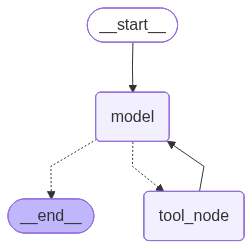

In [21]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [22]:
config = {
    "configurable": {
        "thread_id": 7
    }
}

async for event in graph.astream_events({
    "messages": [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content="Give me the climate change essay in 100 words")
    ],
}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Give me the climate changeessay in 100 words', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d5d9f-97e8-7dd0-b8f9-a444be8e3a16', 'metadata': {'thread_id': 7, 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Give me the climate changeessay in 100 words', additional_kwargs={}, response_metadata={}, id='20ce24e3-f95c-4d2a-9069-aa9026ca6906')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '019d5d9f-97e9-7cb0-aa50-156580599ca0', 'metadata': {'thread_id': 7, 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:dee53743-5f69-f952-cfce-2498d01f6f27'}, 'parent_ids': ['019d5d9f-97e8-7dd0-b8f9-a444be8e3a16']}
{'event': 'on_chat_m